### Facial Embedding Process
**Importation of Necessary Libraries**

In [1]:
# -- imports the face_recognition library, which provides tools for facial detection and recognition
import face_recognition 

# -- imports the OpenCV library for image and video processing
import cv2 

# -- imports the operating system module to interact with the operating system in reading files and system paths
import os 

# -- imports the pickle module for saving and loading of the facial embedding and classification model, respectively
import pickle 


In [2]:
encodings = [] # defines a list for storing the facial embeddings
labels = [] # defines a list for storing facial labels

base_path = "Structured_Data_Set_for_990_Images" # path to stored dataset

This block of code loops through a folder called ***Structured_Data_Set_for_990_Images*** containing subfolders (each subfolder representing a different person), reads each image, detects faces, encodes them, and stores the encodings with corresponding labels (names).

In [3]:
# loops through each folder inside the base directory (N.B: Each Folder is named after a person)

for person_folder in os.listdir(base_path):
    
    person_path = os.path.join(base_path, person_folder) # builds the full path to the person's folder

    # checks and verifies if the current path is a directory
    if os.path.isdir(person_path):

        # loops through each image inside the current person's folder
        for img_name in os.listdir(person_path):
            img_path = os.path.join(person_path, img_name) # builds the full path to the current image
            img = face_recognition.load_image_file(img_path) # loads the current image using the face_recognition library
            face_locations = face_recognition.face_locations(img) # detects all face locations in the loaded image
            face_enc = face_recognition.face_encodings(img, face_locations) # encodes the face found in the image into a 128 one-dimensional feature vector

            # checks and verifies that a face encoding was found/done
            if face_enc:
                encodings.append(face_enc[0]) # appends the 128-dimensional vector to the "encodings" list earlier defined
                labels.append(person_folder) # appends the person's name corresponding to the image


#### Saving the Facial Embeddings to a .pkl File

In [ ]:
# Save Facial Embeddings to a file
data = {"encodings": encodings, "labels": labels} # creates a dictionary object with 2 keys: "encodings", the 128 -d vector and labes, the corresponding names for each person

# opens a new pickle file in binary mode for storing the Facial Encodings
with open("face_encodings.pkl", "wb") as f:
    pickle.dump(data, f) # uses the pickle library to serialize the dictionary data and write it to the opened file

print("Face embeddings and labels saved to 'face_encodings.pkl'") # prints confirmation message for sucessful saving process

### Training/fitting the KNN Algorithm to the Facial Embeddings
This block of code imports the KNN classifier from Sci-Kit learn libray, creates an instance of the classifier with ***3 neighbors*** (i.e considers the 3 closest neighbors for voting) and weights set to ***distance*** to give close neighbors more influence (i.e closer = higher weight)

In [4]:
from sklearn.neighbors import KNeighborsClassifier # imports KNN classifier from sci-kit learn

knn = KNeighborsClassifier(n_neighbors=3, weights='distance') # creates an instance of the KNN classifier 
knn.fit(encodings, labels) # trains the KNN algorithm using the saved facial encoding and corresponding labels

,n_neighbors,3
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


#### Saving the KNN Model to a .pkl File

In [5]:
# opens a new pickle file in binary mode for storing the trained KNN model
with open("knn_model.pkl", "wb") as f:
    pickle.dump(knn, f) # uses the pickle library to serialize the trained KNN model and write it to the opened file

print("KNN model saved to 'knn_model.pkl'") # prints a confirmation message for successful storage of the KNN model

KNN model saved to 'knn_model.pkl'


### Testing/Inference Process
**Testing the KNN Model on an Image**

In [7]:
frame = cv2.imread("test1.jpg")  # reads the test image file into a Numpy array using OpenCV library
face_locations = face_recognition.face_locations(frame) # detects the face locations in the read image
face_encodings = face_recognition.face_encodings(frame, face_locations) # generates the equivalent 128-dimensional vector for each detected face in the image using their locations

# loops through each face encoding generated
for enc in face_encodings:
    prediction = knn.predict([enc]) # predicts the person's identity using the trained KNN model
    print("Predicted:", prediction) # prints the detected name


Predicted: ['Victor_Rizama']


**Testing the KNN Model on a Video**

In [8]:
import os # imports the operating system module to interact with the operating system in reading files and system paths
import glob # imports the glob module to find file paths matching a person
import cv2 # imports the OpenCV library for image and video processing
import face_recognition # imports the face_recognition library, which provides tools for facial detection and recognition

In [9]:
# path to folder containing input .mp4 videos
input_dir = "Collected_Test_Videos"
# path to folder where processed videos will be saved
output_dir = "output_videos"

# creates output directory if not exists
os.makedirs(output_dir, exist_ok=True)

# iterates over all .mp4 files in the input directory
for video_path in glob.glob(os.path.join(input_dir, "*.mp4")):
    video_name = os.path.basename(video_path) # extracts the name of the video file
    output_path = os.path.join(output_dir, video_name) # defined the full path for the annotaed videos

    # opens video for capturing/reading
    cap = cv2.VideoCapture(video_path)

    # checks if the video file was opened successfully
    if not cap.isOpened():
        print(f"Error opening video file {video_path}") # error message
        continue # skips to the next video if the current one fails to open

    # gets video properties
    fps = cap.get(cv2.CAP_PROP_FPS) # gets the frames per second
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) # gets the frame's width
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) # get's the frame's height
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")  # specifies output video format

    # initializes video writer object to save annotated output video
    writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    print(f"Processing {video_name} at {fps} FPS, resolution {width}x{height}")

    frame_count = 0 # counter to track the number of frames processed
    while True:

        # reads the next frame from the video
        ret, frame = cap.read()
        if not ret:
            break # exits the loop if NO frame is returned
        frame_count += 1 # increments the frame counter

        # converts frame from BGR (OpenCV) to RGB (face_recognition)
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # detects faces and compute encodings
        face_locations = face_recognition.face_locations(rgb_frame)
        face_encodings = face_recognition.face_encodings(rgb_frame, face_locations)

        # loops through each detected face
        for (top, right, bottom, left), enc in zip(face_locations, face_encodings):
            
            # draws a green bounding box around the face
            cv2.rectangle(frame, (left, top), (right, bottom), (0, 255, 0), 2)

            # predicts the identity of the encoding with the KNN model
            prediction = knn.predict([enc])[0] 
            label = str(prediction) # converts prediction to a string

            # draws a filled rectangle for the label background below the face
            cv2.rectangle(frame, (left, bottom - 20), (right, bottom), (0, 255, 0), cv2.FILLED)
            
            # overlays the predicted name on the video frame
            cv2.putText(frame, label, (left + 5, bottom - 5), cv2.FONT_HERSHEY_SIMPLEX,
                        0.5, (0, 0, 0), 1)

        # writes the annotated frame to the output video
        writer.write(frame)

    # release the video capture to free system resources
    cap.release()
    writer.release()
    print(f"Saved annotated video to {output_path} with {frame_count} frames.")

print("All videos processed.") # prints message after all vidoes have been processed.


All videos processed.


**Testing KNN Model on Live Webcam**

In [10]:
import cv2 # imports the OpenCV library for image and video processing
import face_recognition # imports the face_recognition library, which provides tools for facial detection and recognition
import pickle # imports the pickle module for saving and loading of the facial embedding and classification model respectively
import os # imports the operating system module to interact with the operating system in reading files and system paths
import time # imports the "time" module to work with time-related functions like delays
import csv # imports the "csv" module to read and write to a CSV file
from datetime import datetime # imports the "datetime" library to work with data and time stamps
from win32com.client import Dispatch # imports the "Dispatch" method to enable windows text-to-speech (TTS) functionality

# function to speak a message aloud
def speak(str1):
    speak = Dispatch("SAPI.SpVoice") # creates a voice engine object using Windows Speech API (SAPI)
    speak.Speak(str1) # uses the speak method to say the message aloud

# loads KNN model in read binary mode
with open('knn_model.pkl', 'rb') as f:
    knn = pickle.load(f) # deserializes the contents of the file and stores it in avariable "knn"

# defining column names for the CSV file
COL_NAMES = ['NAME', 'TIME']

# load background display image
imgBackground = cv2.imread("background_.png")

# starts webcam
video = cv2.VideoCapture(0)

# # Load Haar Cascade for face detection
facedetect = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

# loops to continuously read frames from the web camera
while True:
    ret, frame = video.read() # captures a single frame from the web camera
    
    # if web came fails to read a frame, exits the loop and stops the program
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) # converts the read frame to grayscale, initially required by HaarCascade frontal face detector
    faces = facedetect.detectMultiScale(gray, 1.3, 5) # detects faces using OpenCV's Haar Cascade Classifier

    # loops through all detected faces
    for (x, y, w, h) in faces:
        crop_img = frame[y:y+h, x:x+w] # crops the face region from the original frame
        # gray_crop = cv2.cvtColor(crop_img, cv2.COLOR_BGR2GRAY) 
        resized_crop = cv2.resize(crop_img, (400, 400)) # resizes the cropped face to 400 x 400 pixels for consistency

        # Convert to RGB for face_recognition
        rgb_crop = cv2.cvtColor(resized_crop, cv2.COLOR_BGR2RGB)
        

        # Detect face locations and encodings
        face_locations = face_recognition.face_locations(rgb_crop)
        face_encodings = face_recognition.face_encodings(rgb_crop, face_locations)

        # loops through each detected face and its corresponding encoding
        for (top, right, bottom, left), enc in zip(face_locations, face_encodings):
            prediction = knn.predict([enc])[0] # uses the KNN model to predict the identity of the face
            label = str(prediction) # stores the predicted names as a string to ensure compatibility with OpenCv's text functions

            # Draw bounding box and label on original frame
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2) # draws a green rectangle around the detected face on the main frame
            cv2.rectangle(frame, (x, y - 20), (x + w, y), (0, 255, 0), cv2.FILLED) # draws a filled rectangle above the face box to act as the label background
            cv2.putText(frame, label, (x + 5, y - 5), cv2.FONT_HERSHEY_SIMPLEX,
                        0.5, (0, 0, 0), 1) # writes the predicted name on the filled rectangle using black font

            # Record attendance
            ts = time.time() # captures the current time stamp in seconds
            date = datetime.fromtimestamp(ts).strftime("%d-%m-%Y") # converts the timestamp to a human-readable data format like "08-08-2025"
            timestamp = datetime.fromtimestamp(ts).strftime("%H:%M:%S") # converts the timestamp to the current time, like 15:30:12
            attendance = [label, timestamp] # prepares the attendance entry with the name and time.
            exist = os.path.isfile("Attendance_" + date + ".csv") # checks if a CSV file for today's date already exists

    # Overlay frame on background
    imgBackground[162:162 + 480, 55:55 + 640] = frame # places the frame with recognition results onto a predefined background image at a specific function
    cv2.imshow("Frame", imgBackground)  # displays the updated background with the camera frame and overlaid rectangles/text.

    k = cv2.waitKey(1)

    # checks to know if keyboard key "o" is pressed....
    if k == ord('o'):
        speak("Attendance Taken") # calls the "speak" function earlier defined to voice "Attendance Taken" with Windows TTS API: SAPI
        time.sleep(2) # delays program for 2 milliseconds

        # checks to know if the attendance list has been created to prevent writing an empty or undefined data
        if attendance:

            # checks to know if the CSV file for today already exists
            if exist:
                # opens the file in append mode so that new rows can be added to the end of the file
                with open("Attendance_" + date + ".csv", "+a", newline='') as csvfile:
                    writer = csv.writer(csvfile) # creates a CSV writer object to write rows to the file
                    writer.writerow(attendance) # appends current attendance entry

            # incase the CSV file does not exist, creates a new one and also writes the header
            else:
                
                with open("Attendance_" + date + ".csv", "+a", newline='') as csvfile:
                    # opens the file in append mode so that new rows can be added to the end of the file
                    writer = csv.writer(csvfile) # creates a CSV writer object to write rows to the file
                    writer.writerow(COL_NAMES) # writes a header row to the file
                    writer.writerow(attendance) # appends current attendance entry

    # incase the user presses the 'q' key, the program exits the "while True" loop
    elif k == ord('q'):
        break

video.release() # releases the web camera video feed
cv2.destroyAllWindows() # closes the OpenCV windows


### KNN Model Evaluation

#### Model Evaluation on Videos

In [12]:
import cv2 # imports OpenCV library for Videl processing and frame extraction
import face_recognition # imports face recognition library for detecting and encoding human faces
import os # imports operating system library provides functions for interacting with the operating system
import pickle # imports the pickle module for saving and loading of the facial embedding and classification model respectively
from sklearn.metrics import classification_report, confusion_matrix # imports classification report and confusion matrix libraries for evaluation metrics

# Loads the model
with open("knn_model.pkl", "rb") as f:
    knn = pickle.load(f)

# Initializes lists to store the true and predicted labels
true_labels = [] # holds the actial person's labels 
pred_labels = [] # holds the predicted person's labels

video_test_path = "test_videos" # defines the path to the directory containing test video samples

# Iterates through each person's folder and test videos
for person in os.listdir(video_test_path):
    person_folder = os.path.join(video_test_path, person)

    # Checks to see if the path is a directory
    if os.path.isdir(person_folder):
        for video_name in os.listdir(person_folder):
            video_path = os.path.join(person_folder, video_name)
            print(f"Processing: {video_path}")

            # Opens the video file for frame by frame reading
            cap = cv2.VideoCapture(video_path)
            frame_count = 0 # counts the number of frames processed
            
            while True:
                ret, frame = cap.read() # tries to read the next frame
                if not ret: # if no frame is returned (it means end of video)
                    break
                frame_count += 1

                # Converts the frame from BGR (OpenCV default) to RGB (used by the face_recognition library)
                rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

                # Detects face locations and extracts their encodings
                face_locations = face_recognition.face_locations(rgb_frame)
                face_encodings = face_recognition.face_encodings(rgb_frame, face_locations)

                # Predicts the identity of each detected face using the trained KNN model
                for enc in face_encodings:
                    pred = knn.predict([enc])[0] # predicts the label for the current face encoding
                    pred_labels.append(pred) # appends the predicted label
                    true_labels.append(person) # appends the actual label (from the folder name)

            # Releases the video capture resources after processing
            cap.release()
            print(f"Finished {video_name}, frames read: {frame_count}")

# Evaluates the model's performance on the videos using sklearn metrics
print(classification_report(true_labels, pred_labels)) # prints the precision, recall, and F1-Score for each class
cm = confusion_matrix(true_labels, pred_labels) # computes the confusion matrix for visualizing  misclassification
print(cm)


Processing: test_videos\Kehinde_Adebayo\test13.mp4
Finished test13.mp4, frames read: 409
Processing: test_videos\Victor_Rizama\test1.mp4
Finished test1.mp4, frames read: 125
                 precision    recall  f1-score   support

Kehinde_Adebayo       1.00      1.00      1.00       409
  Victor_Rizama       1.00      1.00      1.00       117

       accuracy                           1.00       526
      macro avg       1.00      1.00      1.00       526
   weighted avg       1.00      1.00      1.00       526

[[409   0]
 [  0 117]]


#### Model Evaluation on Images

In [15]:
import os # imports operating system library provides functions for interacting with the operating system
import face_recognition # imports face recognition library for detecting and encoding human faces
import pickle # imports the pickle module for saving and loading of the facial embedding and classification model respectively
from sklearn.metrics import classification_report, confusion_matrix # imports classification report and confusion matrix libraries for evaluation metrics


# Load model
with open("knn_model.pkl", "rb") as f:
    knn = pickle.load(f)

# Initializes lists to store the true and predicted labels
true_labels = [] # holds the actial person's labels 
pred_labels = [] # holds the predicted person's labels

test_base_path = "test_images" # defines the path to the directory containing test image samples

# Loops through each person's folder in the test dataset
for person in os.listdir(test_base_path):
    person_path = os.path.join(test_base_path, person)

    # Ensures the current item is a directory (representing a person)
    if os.path.isdir(person_path):
        # Loops through all images in the current person's folder
        for img_name in os.listdir(person_path):
            img_path = os.path.join(person_path, img_name)

            # Loads the image file into memory
            img = face_recognition.load_image_file(img_path)
            # Detects face locations in the image 
            face_locations = face_recognition.face_locations(img)
            # Extracts 128-dimensional facial embeddings for each detected face
            face_encodings = face_recognition.face_encodings(img, face_locations)

            # Confirms if atleast 1 face is detected in the image
            if face_encodings:

                # Predicts the identity of the first detected face using the trained KNN model
                pred = knn.predict([face_encodings[0]])[0]

                # Appends the predicted and true labels for later evaluation
                pred_labels.append(pred)
                true_labels.append(person)  # uses the folder name as the ground truth label

# Evaluates the Model's Performance
print(classification_report(true_labels, pred_labels)) # prints classification metrics specifically the precision, recall and F1-Score
cm = confusion_matrix(true_labels, pred_labels) # computes and prints the confusion matrix to visualize correct vs. incorrect classifications
print(cm)


                 precision    recall  f1-score   support

Kehinde_Adebayo       1.00      1.00      1.00       629
    Rufai_Ahmad       1.00      1.00      1.00       462
  Victor_Rizama       1.00      1.00      1.00       659

       accuracy                           1.00      1750
      macro avg       1.00      1.00      1.00      1750
   weighted avg       1.00      1.00      1.00      1750

[[629   0   0]
 [  1 461   0]
 [  0   0 659]]


#### Confusion Matrix Plot for Still Image Test Results

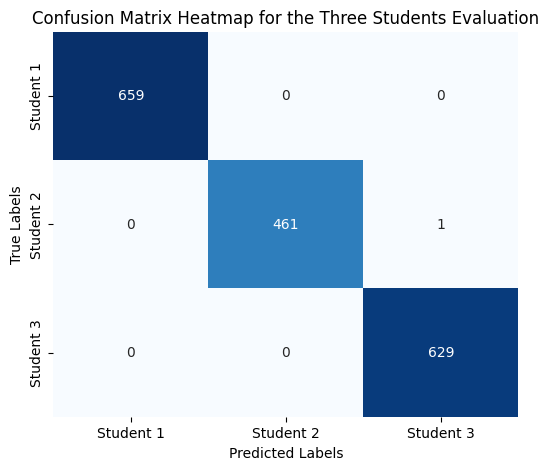

In [17]:
import matplotlib.pyplot as plt # imports matplotlib for plotting and visualizing data 
import seaborn as sns # imports the seaborn library for creating visually appealing statistical graphics
import numpy as np # imports the numpy library for numerical operations and handling arrays

# Confusion matrix values (Diagonal elements indicate correctly classified instances)
conf_matrix = np.array([[659, 0, 0],
                        [0, 461, 1],
                        [0, 0, 629]])

# Labels for students
labels = ["Student 1", "Student 2", "Student 3"]

# Creates the heatmap
plt.figure(figsize=(6, 5)) # sets the figure to a width of 6 and height of 4
sns.heatmap(conf_matrix, # the confusion matrix data
            annot=True, # displays numerical values inside each cell
            fmt="d", # formats numbers as integers
            cmap="Blues", # uses blue color gradient
            xticklabels=labels, # sets predicted class labels along the x-axis
            yticklabels=labels, # sets true class labels along the y-axis
            cbar=False # disables color bar on the right for simplicity
           )

# Customizes axis labels and plot title
plt.xlabel("Predicted Labels") # defines the label for the x-axis
plt.ylabel("True Labels") # defines the label for the y-axis
plt.title("Confusion Matrix Heatmap for the Three Students Evaluation") # defines the plot title

# Save the plot as an image file
plt.savefig("confusion_matrix_heatmap.png", # defines the output filename
            dpi=300, # sets the image resolution
            bbox_inches="tight" # removes extra whitespace around the figure
           )

plt.show() # displays the heatmap window


#### Confusion Matrix Plot for Videos (Moving Images)

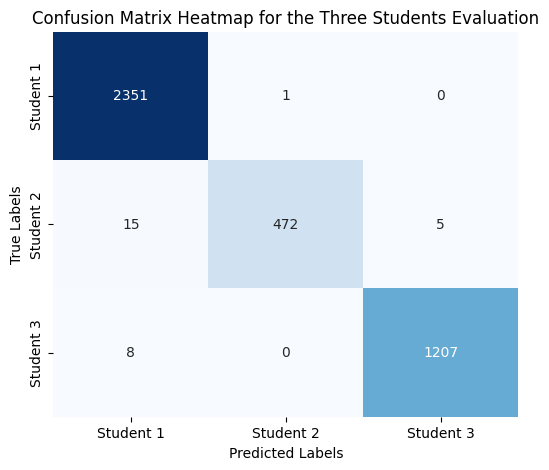

In [18]:
import matplotlib.pyplot as plt # imports matplotlib for plotting and visualizing data 
import seaborn as sns # imports the seaborn library for creating visually appealing statistical graphics
import numpy as np # imports the numpy library for numerical operations and handling arrays

# Confusion matrix values (Diagonal elements indicate correctly classified instances)
conf_matrix = np.array([[2351, 1, 0],
                        [  15,  472,    5],
                        [   8,    0, 1207]])

# Labels for students
labels = ["Student 1", "Student 2", "Student 3"]

# Create the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, cbar=False)

# Customizes axis labels and plot title
plt.xlabel("Predicted Labels") # defines the label for the x-axis
plt.ylabel("True Labels") # defines the label for the y-axis
plt.title("Confusion Matrix Heatmap for the Three Students Evaluation") # defines the plot title

# Save the plot as an image file
plt.savefig("confusion_matrix_heatmap.png", # defines the output filename
            dpi=300, # sets the image resolution
            bbox_inches="tight" # removes extra whitespace around the figure
           )

plt.show() # displays the heatmap window
